# Eksperyment porównawczy: Embedowanie profili naukowców

Ten notatnik porównuje 3 różne modele embedowania:
- **all-MiniLM-L6-v2** (szybki, lekki model)
- **all-mpnet-base-v2** (większy, bardziej zaawansowany)
- **paraphrase-multilingual-MiniLM-L12-v2** (wielojęzyczny)

Dla każdego modelu tworzymy profile naukowców poprzez:
1. **Embedowanie pełnych abstraktów**
2. **Embedowanie samych tytułów**

**Łącznie: 6 różnych kombinacji (3 modele × 2 typy danych)**

## 1. Instalacja bibliotek

In [ ]:
!pip install sentence-transformers scikit-learn pandas matplotlib seaborn -q

## 2. Import bibliotek

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import time
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 3. Wczytanie danych

**Wybierz jedną z dwóch opcji poniżej:**
- **Opcja A**: Google Colab (montowanie Google Drive)
- **Opcja B**: Lokalne Jupyter Notebook (ścieżki lokalne)

Dane powinny zawierać:
- Plik naukowców z kolumną ORCID
- Plik prac z kolumnami: ORCID autora, tytuł, abstrakt

### OPCJA A: Google Colab (użyj tej komórki na Colab)

In [ ]:
# =============================================================================
# OPCJA A: GOOGLE COLAB
# Odkomentuj i uruchom tę komórkę jeśli pracujesz na Google Colab
# =============================================================================

from google.colab import drive
import os

# Montowanie Google Drive
drive.mount('/content/drive')

# DOSTOSUJ ŚCIEŻKI DO SWOICH PLIKÓW
BASE_DIR = '../data'
SCIENTISTS_FILE = os.path.join(BASE_DIR, 'scientists_with_identifiers.csv')
WORKS_FILE = os.path.join(BASE_DIR, 'openalex_all_results_complete.csv')

# Funkcje pomocnicze
def clean_orcid(orcid_value):
    """Czyści format ORCID (usuwa prefiksy URL)."""
    if pd.isna(orcid_value):
        return None
    cleaned = str(orcid_value).replace('https://orcid.org/', '')
    cleaned = cleaned.replace('http://orcid.org/', '')
    return cleaned.strip()

def find_orcid_column(dataframe):
    """Znajduje kolumnę ORCID w DataFrame."""
    orcid_columns = [col for col in dataframe.columns if 'orcid' in col.lower()]
    if not orcid_columns:
        raise ValueError("Brak kolumny ORCID w pliku!")
    return orcid_columns[0]

# Wczytanie danych
print("📂 Wczytywanie danych z Google Drive...")
print(f"   Ścieżka bazowa: {BASE_DIR}")

# Sprawdzenie istnienia plików
if not os.path.exists(SCIENTISTS_FILE):
    raise FileNotFoundError(f"Nie znaleziono pliku: {SCIENTISTS_FILE}")
if not os.path.exists(WORKS_FILE):
    raise FileNotFoundError(f"Nie znaleziono pliku: {WORKS_FILE}")

# Wczytanie CSV
df_scientists = pd.read_csv(SCIENTISTS_FILE)
df_works = pd.read_csv(WORKS_FILE)

# Czyszczenie ORCID
df_scientists['clean_orcid'] = df_scientists['orcid'].apply(clean_orcid)
work_orcid_column = find_orcid_column(df_works)
df_works['clean_main_orcid'] = df_works[work_orcid_column].apply(clean_orcid)

print(f"✅ Załadowano {len(df_scientists)} naukowców i {len(df_works)} prac.")
print(f"   Kolumna ORCID w scientists: 'orcid' → 'clean_orcid'")
print(f"   Kolumna ORCID w works: '{work_orcid_column}' → 'clean_main_orcid'")

# Wyświetlenie podstawowych informacji
print(f"\n📊 Podgląd danych:")
print(f"\nNaukowcy - dostępne kolumny: {df_scientists.columns.tolist()}")
print(f"Prace - dostępne kolumny: {df_works.columns.tolist()}")

Mounted at /content/drive
📂 Wczytywanie danych z Google Drive...
   Ścieżka bazowa: ../data
✅ Załadowano 164 naukowców i 4819 prac.
   Kolumna ORCID w scientists: 'orcid' → 'clean_orcid'
   Kolumna ORCID w works: 'main_author_orcid' → 'clean_main_orcid'

📊 Podgląd danych:

Naukowcy - dostępne kolumny: ['profile_id', 'full_name', 'academic_title', 'first_name', 'last_name', 'position', 'profile_url', 'image_url', 'affiliations', 'orcid', 'google_scholar_id', 'google_scholar_url', 'scopus_id', 'scopus_url', 'europepmc', 'crossref', 'researchgate', 'other_links', 'clean_orcid']
Prace - dostępne kolumny: ['main_author_orcid', 'openalex_id', 'title', 'publication_year', 'publication_date', 'doi', 'type', 'cited_by_count', 'journal', 'topics', 'co_authors', 'co_author_orcids', 'num_co_authors', 'abstract', 'keywords', 'clean_main_orcid']


### OPCJA B: Lokalne Jupyter Notebook (użyj tej komórki lokalnie)

In [ ]:
# =============================================================================
# OPCJA B: LOKALNE ŚRODOWISKO
# Odkomentuj i uruchom tę komórkę jeśli pracujesz lokalnie
# =============================================================================

# import os

# # DOSTOSUJ ŚCIEŻKI DO SWOICH PLIKÓW LOKALNYCH
# SCIENTISTS_FILE = 'data/scientists_with_identifiers.csv'
# WORKS_FILE = 'data/openalex_all_results_complete.csv'

# # Lub użyj pełnych ścieżek, np.:
# # SCIENTISTS_FILE = '/home/user/Documents/research/scientists_with_identifiers.csv'
# # WORKS_FILE = '/home/user/Documents/research/openalex_all_results_complete.csv'

# # Funkcje pomocnicze
# def clean_orcid(orcid_value):
#     """Czyści format ORCID (usuwa prefiksy URL)."""
#     if pd.isna(orcid_value):
#         return None
#     cleaned = str(orcid_value).replace('https://orcid.org/', '')
#     cleaned = cleaned.replace('http://orcid.org/', '')
#     return cleaned.strip()

# def find_orcid_column(dataframe):
#     """Znajduje kolumnę ORCID w DataFrame."""
#     orcid_columns = [col for col in dataframe.columns if 'orcid' in col.lower()]
#     if not orcid_columns:
#         raise ValueError("Brak kolumny ORCID w pliku!")
#     return orcid_columns[0]

# # Wczytanie danych
# print("📂 Wczytywanie danych lokalnie...")
# print(f"   Plik naukowców: {SCIENTISTS_FILE}")
# print(f"   Plik prac: {WORKS_FILE}")

# # Sprawdzenie istnienia plików
# if not os.path.exists(SCIENTISTS_FILE):
#     raise FileNotFoundError(f"Nie znaleziono pliku: {SCIENTISTS_FILE}")
# if not os.path.exists(WORKS_FILE):
#     raise FileNotFoundError(f"Nie znaleziono pliku: {WORKS_FILE}")

# # Wczytanie CSV
# df_scientists = pd.read_csv(SCIENTISTS_FILE)
# df_works = pd.read_csv(WORKS_FILE)

# # Czyszczenie ORCID
# df_scientists['clean_orcid'] = df_scientists['orcid'].apply(clean_orcid)
# work_orcid_column = find_orcid_column(df_works)
# df_works['clean_main_orcid'] = df_works[work_orcid_column].apply(clean_orcid)

# print(f"✅ Załadowano {len(df_scientists)} naukowców i {len(df_works)} prac.")
# print(f"   Kolumna ORCID w scientists: 'orcid' → 'clean_orcid'")
# print(f"   Kolumna ORCID w works: '{work_orcid_column}' → 'clean_main_orcid'")

# # Wyświetlenie podstawowych informacji
# print(f"\n📊 Podgląd danych:")
# print(f"\nNaukowcy - dostępne kolumny: {df_scientists.columns.tolist()}")
# print(f"Prace - dostępne kolumny: {df_works.columns.tolist()}")

## 4. Przygotowanie danych

Sprawdzamy strukturę danych i identyfikujemy potrzebne kolumny.

In [ ]:
# Weryfikacja, czy dane zostały wczytane
try:
    print("📋 Sprawdzanie załadowanych danych...\n")

    print(f"✅ df_scientists: {len(df_scientists)} rekordów")
    print(f"   Kolumny: {df_scientists.columns.tolist()}\n")

    print(f"✅ df_works: {len(df_works)} rekordów")
    print(f"   Kolumny: {df_works.columns.tolist()}\n")

    # Wyświetl przykładowe dane
    print("📊 Przykładowy naukowiec:")
    display(df_scientists.head(1).T)

    print("\n📄 Przykładowa praca:")
    display(df_works.head(1).T)

except NameError:
    print("❌ BŁĄD: Dane nie zostały załadowane!")
    print("💡 Uruchom najpierw OPCJĘ A (Colab) lub OPCJĘ B (lokalne) z poprzedniej sekcji.")
    raise

📋 Sprawdzanie załadowanych danych...

✅ df_scientists: 164 rekordów
   Kolumny: ['profile_id', 'full_name', 'academic_title', 'first_name', 'last_name', 'position', 'profile_url', 'image_url', 'affiliations', 'orcid', 'google_scholar_id', 'google_scholar_url', 'scopus_id', 'scopus_url', 'europepmc', 'crossref', 'researchgate', 'other_links', 'clean_orcid']

✅ df_works: 4819 rekordów
   Kolumny: ['main_author_orcid', 'openalex_id', 'title', 'publication_year', 'publication_date', 'doi', 'type', 'cited_by_count', 'journal', 'topics', 'co_authors', 'co_author_orcids', 'num_co_authors', 'abstract', 'keywords', 'clean_main_orcid']

📊 Przykładowy naukowiec:


,0
profile_id,UAM12847
full_name,prof. dr hab. Wojciech Buszkowski
academic_title,prof. dr hab.
first_name,Wojciech
last_name,Buszkowski
position,profesor Senior
profile_url,https://researchportal.amu.edu.pl/info/author/...
image_url,https://researchportal.amu.edu.pl/javax.faces....
affiliations,Wydział Matematyki i Informatyki; Szkoła Nauk ...
orcid,0000-0002-2950-0864



📄 Przykładowa praca:


,0
main_author_orcid,0000-0002-2950-0864
openalex_id,W1976366395
title,On Action Logic: Equational Theories of Action...
publication_year,2006
publication_date,2006-08-23
doi,https://doi.org/10.1093/logcom/exl036
type,article
cited_by_count,34
journal,Journal of Logic and Computation
topics,"Advanced Algebra and Logic; Logic, Reasoning, ..."


### Identyfikacja kolumn z tytułami i abstraktami

In [ ]:
# Znajdujemy kolumny z tytułami i abstraktami
# DOSTOSUJ NAZWY KOLUMN DO SWOICH DANYCH

# Przykładowe nazwy kolumn - zmień według swoich danych:
TITLE_COLUMN = 'title'  # lub 'Title', 'publication_title', etc.
ABSTRACT_COLUMN = 'abstract'  # lub 'Abstract', 'ab', 'description', etc.

# Sprawdzenie czy kolumny istnieją
print("🔍 Weryfikacja kolumn...\n")

if TITLE_COLUMN not in df_works.columns:
    print(f"⚠️  Kolumna '{TITLE_COLUMN}' nie istnieje w df_works!")
    print(f"   Dostępne kolumny: {df_works.columns.tolist()}")
    print(f"   Ustaw TITLE_COLUMN na właściwą nazwę kolumny.")
else:
    print(f"✅ Kolumna z tytułami: '{TITLE_COLUMN}'")
    non_null_titles = df_works[TITLE_COLUMN].notna().sum()
    print(f"   Wypełnionych: {non_null_titles}/{len(df_works)} ({non_null_titles/len(df_works)*100:.1f}%)")

if ABSTRACT_COLUMN not in df_works.columns:
    print(f"\n⚠️  Kolumna '{ABSTRACT_COLUMN}' nie istnieje w df_works!")
    print(f"   Dostępne kolumny: {df_works.columns.tolist()}")
    print(f"   Ustaw ABSTRACT_COLUMN na właściwą nazwę kolumny.")
else:
    print(f"\n✅ Kolumna z abstraktami: '{ABSTRACT_COLUMN}'")
    non_null_abstracts = df_works[ABSTRACT_COLUMN].notna().sum()
    print(f"   Wypełnionych: {non_null_abstracts}/{len(df_works)} ({non_null_abstracts/len(df_works)*100:.1f}%)")

🔍 Weryfikacja kolumn...

✅ Kolumna z tytułami: 'title'
   Wypełnionych: 4817/4819 (100.0%)

✅ Kolumna z abstraktami: 'abstract'
   Wypełnionych: 3346/4819 (69.4%)


### Agregacja danych dla każdego naukowca

In [ ]:
# Łączymy dane naukowców z ich pracami
print("🔗 Łączenie danych naukowców z ich pracami...\n")

# Merge based on ORCID
df_merged = df_works.merge(
    df_scientists[['clean_orcid', 'orcid']],  # Dodajemy oryginalny ORCID dla identyfikacji
    left_on='clean_main_orcid',
    right_on='clean_orcid',
    how='inner'
)

print(f"✅ Połączono {len(df_merged)} prac z naukowcami")
print(f"   Unikalnych naukowców z pracami: {df_merged['clean_orcid'].nunique()}")

# Usunięcie brakujących wartości w kluczowych kolumnach
df_clean = df_merged.dropna(subset=['clean_orcid', TITLE_COLUMN, ABSTRACT_COLUMN]).copy()

print(f"\n🧹 Po usunięciu brakujących wartości:")
print(f"   Prace: {len(df_clean)}")
print(f"   Unikalnych naukowców: {df_clean['clean_orcid'].nunique()}")

# Agregacja - połączenie wszystkich abstraktów i tytułów dla każdego naukowca
print(f"\n📦 Agregacja tekstów dla każdego naukowca...")

author_data = df_clean.groupby('clean_orcid').agg({
    ABSTRACT_COLUMN: lambda x: ' '.join(x.astype(str).tolist()),  # Wszystkie abstrakty razem
    TITLE_COLUMN: lambda x: ' '.join(x.astype(str).tolist()),     # Wszystkie tytuły razem
    'orcid': 'first'  # Zachowujemy oryginalny ORCID dla identyfikacji
}).reset_index()

# Zmiana nazw kolumn dla czytelności
author_data.rename(columns={
    ABSTRACT_COLUMN: 'abstract',
    TITLE_COLUMN: 'title',
    'orcid': 'author_id'
}, inplace=True)

print(f"\n✅ Przygotowano dane dla {len(author_data)} naukowców")
print(f"\n📊 Statystyki długości tekstów:")
print(f"   Średnia długość połączonych abstraktów: {author_data['abstract'].str.len().mean():.0f} znaków")
print(f"   Średnia długość połączonych tytułów: {author_data['title'].str.len().mean():.0f} znaków")

# Przykład dla pierwszego naukowca
print(f"\n📝 Przykład dla pierwszego naukowca:")
print(f"   ORCID: {author_data.iloc[0]['author_id']}")
print(f"   Długość abstraktów: {len(author_data.iloc[0]['abstract'])} znaków")
print(f"   Długość tytułów: {len(author_data.iloc[0]['title'])} znaków")
print(f"   Fragment abstraktu: {author_data.iloc[0]['abstract'][:200]}...")

🔗 Łączenie danych naukowców z ich pracami...

✅ Połączono 4819 prac z naukowcami
   Unikalnych naukowców z pracami: 116

🧹 Po usunięciu brakujących wartości:
   Prace: 3345
   Unikalnych naukowców: 114

📦 Agregacja tekstów dla każdego naukowca...

✅ Przygotowano dane dla 114 naukowców

📊 Statystyki długości tekstów:
   Średnia długość połączonych abstraktów: 24462 znaków
   Średnia długość połączonych tytułów: 2084 znaków

📝 Przykład dla pierwszego naukowca:
   ORCID: 0000-0001-5016-1433
   Długość abstraktów: 1764 znaków
   Długość tytułów: 444 znaków
   Fragment abstraktu: We characterize composition operators on spaces of real analytic functions which are open onto their images. We give an example of a semiproper map $\varphi $ such that the associated composition oper...


## 5. Konfiguracja modeli

Definiujemy 3 modele do porównania:

In [ ]:
MODELS = {
    'MiniLM-L6': 'all-MiniLM-L6-v2',
    'Specter':'allenai-specter',
    'MPNet-Base': 'all-mpnet-base-v2',
    'Multilingual-MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
}

# Typy embedowania
EMBEDDING_TYPES = ['abstract', 'title']

print("Modele do przetestowania:")
for name, model_id in MODELS.items():
    print(f"  - {name}: {model_id}")
print(f"\nTypy embedowania: {EMBEDDING_TYPES}")
print(f"\nŁącznie kombinacji: {len(MODELS)} × {len(EMBEDDING_TYPES)} = {len(MODELS) * len(EMBEDDING_TYPES)}")

Modele do przetestowania:
  - MiniLM-L6: all-MiniLM-L6-v2
  - Specter: allenai-specter
  - MPNet-Base: all-mpnet-base-v2
  - Multilingual-MiniLM: paraphrase-multilingual-MiniLM-L12-v2

Typy embedowania: ['abstract', 'title']

Łącznie kombinacji: 4 × 2 = 8


## 6. Funkcje pomocnicze

In [ ]:
def create_embeddings(texts, model):
    """Tworzy embeddingi dla listy tekstów."""
    return model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

def calculate_similarity_stats(embeddings):
    """Oblicza statystyki podobieństwa między wszystkimi parami embeddingów."""
    similarity_matrix = cosine_similarity(embeddings)

    # Pobierz górny trójkąt (bez diagonali) - unikalne pary
    upper_triangle = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

    return {
        'mean': np.mean(upper_triangle),
        'std': np.std(upper_triangle),
        'min': np.min(upper_triangle),
        'max': np.max(upper_triangle),
        'median': np.median(upper_triangle),
        'matrix': similarity_matrix,
        'values': upper_triangle
    }

def find_most_similar_authors(embeddings, authors, top_n=5):
    """Znajduje najbardziej podobnych autorów dla każdego autora."""
    similarity_matrix = cosine_similarity(embeddings)
    results = {}

    for i, author in enumerate(authors):
        # Pobierz podobieństwa dla tego autora
        similarities = similarity_matrix[i].copy()
        similarities[i] = -1  # Wykluczamy siebie samego

        # Znajdź top N najbardziej podobnych
        top_indices = np.argsort(similarities)[::-1][:top_n]

        results[author] = [
            (authors[idx], similarities[idx])
            for idx in top_indices
        ]

    return results

## 7. Główny eksperyment

Dla każdej kombinacji modelu i typu danych:
1. Ładujemy model
2. Tworzymy embeddingi
3. Obliczamy statystyki
4. Zapisujemy wyniki

In [ ]:
# Słownik do przechowywania wszystkich wyników
results = {}
embeddings_storage = {}

# Lista autorów (identyfikatory ORCID)
authors = author_data['author_id'].tolist()

print("="*80)
print("ROZPOCZĘCIE EKSPERYMENTU")
print("="*80)
print(f"Liczba naukowców do analizy: {len(authors)}")
print(f"Modeli do przetestowania: {len(MODELS)}")
print(f"Typów embedowania: {len(EMBEDDING_TYPES)}")
print(f"Łącznie kombinacji: {len(MODELS) * len(EMBEDDING_TYPES)}")

for model_name, model_id in MODELS.items():
    print(f"\n{'='*80}")
    print(f"MODEL: {model_name} ({model_id})")
    print(f"{'='*80}\n")

    # Ładowanie modelu
    print(f"Ładowanie modelu...")
    start_time = time.time()
    model = SentenceTransformer(model_id)
    load_time = time.time() - start_time
    print(f"✓ Model załadowany w {load_time:.2f}s\n")

    for emb_type in EMBEDDING_TYPES:
        print(f"  → Typ embedowania: {emb_type.upper()}")
        print(f"  {'-'*60}")

        # Przygotowanie tekstów do embedowania
        texts = author_data[emb_type].tolist()

        # Tworzenie embeddingów
        print(f"  Tworzenie embeddingów dla {len(texts)} autorów...")
        start_time = time.time()
        embeddings = create_embeddings(texts, model)
        embed_time = time.time() - start_time

        # Obliczanie statystyk
        stats = calculate_similarity_stats(embeddings)

        # Zapisywanie wyników
        key = f"{model_name}_{emb_type}"
        results[key] = {
            'model_name': model_name,
            'model_id': model_id,
            'embedding_type': emb_type,
            'load_time': load_time,
            'embed_time': embed_time,
            'embedding_dim': embeddings.shape[1],
            'stats': stats
        }
        embeddings_storage[key] = embeddings

        # Wyświetlanie wyników
        print(f"  ✓ Embeddingi utworzone w {embed_time:.2f}s")
        print(f"  Wymiar embeddingów: {embeddings.shape[1]}")
        print(f"  Statystyki podobieństwa (cosine similarity):")
        print(f"    - Średnia: {stats['mean']:.4f}")
        print(f"    - Mediana: {stats['median']:.4f}")
        print(f"    - Std dev: {stats['std']:.4f}")
        print(f"    - Min: {stats['min']:.4f}")
        print(f"    - Max: {stats['max']:.4f}")
        print()

print("="*80)
print("EKSPERYMENT ZAKOŃCZONY")
print("="*80)

ROZPOCZĘCIE EKSPERYMENTU
Liczba naukowców do analizy: 114
Modeli do przetestowania: 4
Typów embedowania: 2
Łącznie kombinacji: 8

MODEL: MiniLM-L6 (all-MiniLM-L6-v2)

Ładowanie modelu...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

✓ Model załadowany w 11.31s

  → Typ embedowania: ABSTRACT
  ------------------------------------------------------------
  Tworzenie embeddingów dla 114 autorów...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  ✓ Embeddingi utworzone w 3.00s
  Wymiar embeddingów: 384
  Statystyki podobieństwa (cosine similarity):
    - Średnia: 0.2742
    - Mediana: 0.2514
    - Std dev: 0.1607
    - Min: -0.1569
    - Max: 1.0000

  → Typ embedowania: TITLE
  ------------------------------------------------------------
  Tworzenie embeddingów dla 114 autorów...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

  ✓ Embeddingi utworzone w 0.69s
  Wymiar embeddingów: 384
  Statystyki podobieństwa (cosine similarity):
    - Średnia: 0.2668
    - Mediana: 0.2259
    - Std dev: 0.1945
    - Min: -0.1650
    - Max: 0.9618

EKSPERYMENT ZAKOŃCZONY


## 8. Podsumowanie wyników

In [ ]:
# Tworzenie tabeli podsumowującej
summary_data = []

for key, result in results.items():
    summary_data.append({
        'Model': result['model_name'],
        'Typ': result['embedding_type'],
        'Wymiar': result['embedding_dim'],
        'Czas ładowania (s)': f"{result['load_time']:.2f}",
        'Czas embedowania (s)': f"{result['embed_time']:.2f}",
        'Śr. podobieństwo': f"{result['stats']['mean']:.4f}",
        'Odch. std': f"{result['stats']['std']:.4f}",
        'Min podobieństwo': f"{result['stats']['min']:.4f}",
        'Max podobieństwo': f"{result['stats']['max']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*120)
print("TABELA PODSUMOWUJĄCA WSZYSTKIE EKSPERYMENTY")
print("="*120)
print(summary_df.to_string(index=False))
print("="*120)


TABELA PODSUMOWUJĄCA WSZYSTKIE EKSPERYMENTY
              Model      Typ  Wymiar Czas ładowania (s) Czas embedowania (s) Śr. podobieństwo Odch. std Min podobieństwo Max podobieństwo
          MiniLM-L6 abstract     384               8.38                 2.63           0.1216    0.1454          -0.2182           1.0000
          MiniLM-L6    title     384               8.38                 0.50           0.1282    0.1561          -0.1697           0.8643
            Specter abstract     768               9.19                 4.77           0.6389    0.1048           0.3670           0.9900
            Specter    title     768               9.19                 2.46           0.6513    0.1014           0.3523           0.9705
         MPNet-Base abstract     768               9.03                 4.42           0.1221    0.1574          -0.1511           1.0000
         MPNet-Base    title     768               9.03                 2.33           0.1466    0.1629          -0.1528       

## 9. Wizualizacja wyników

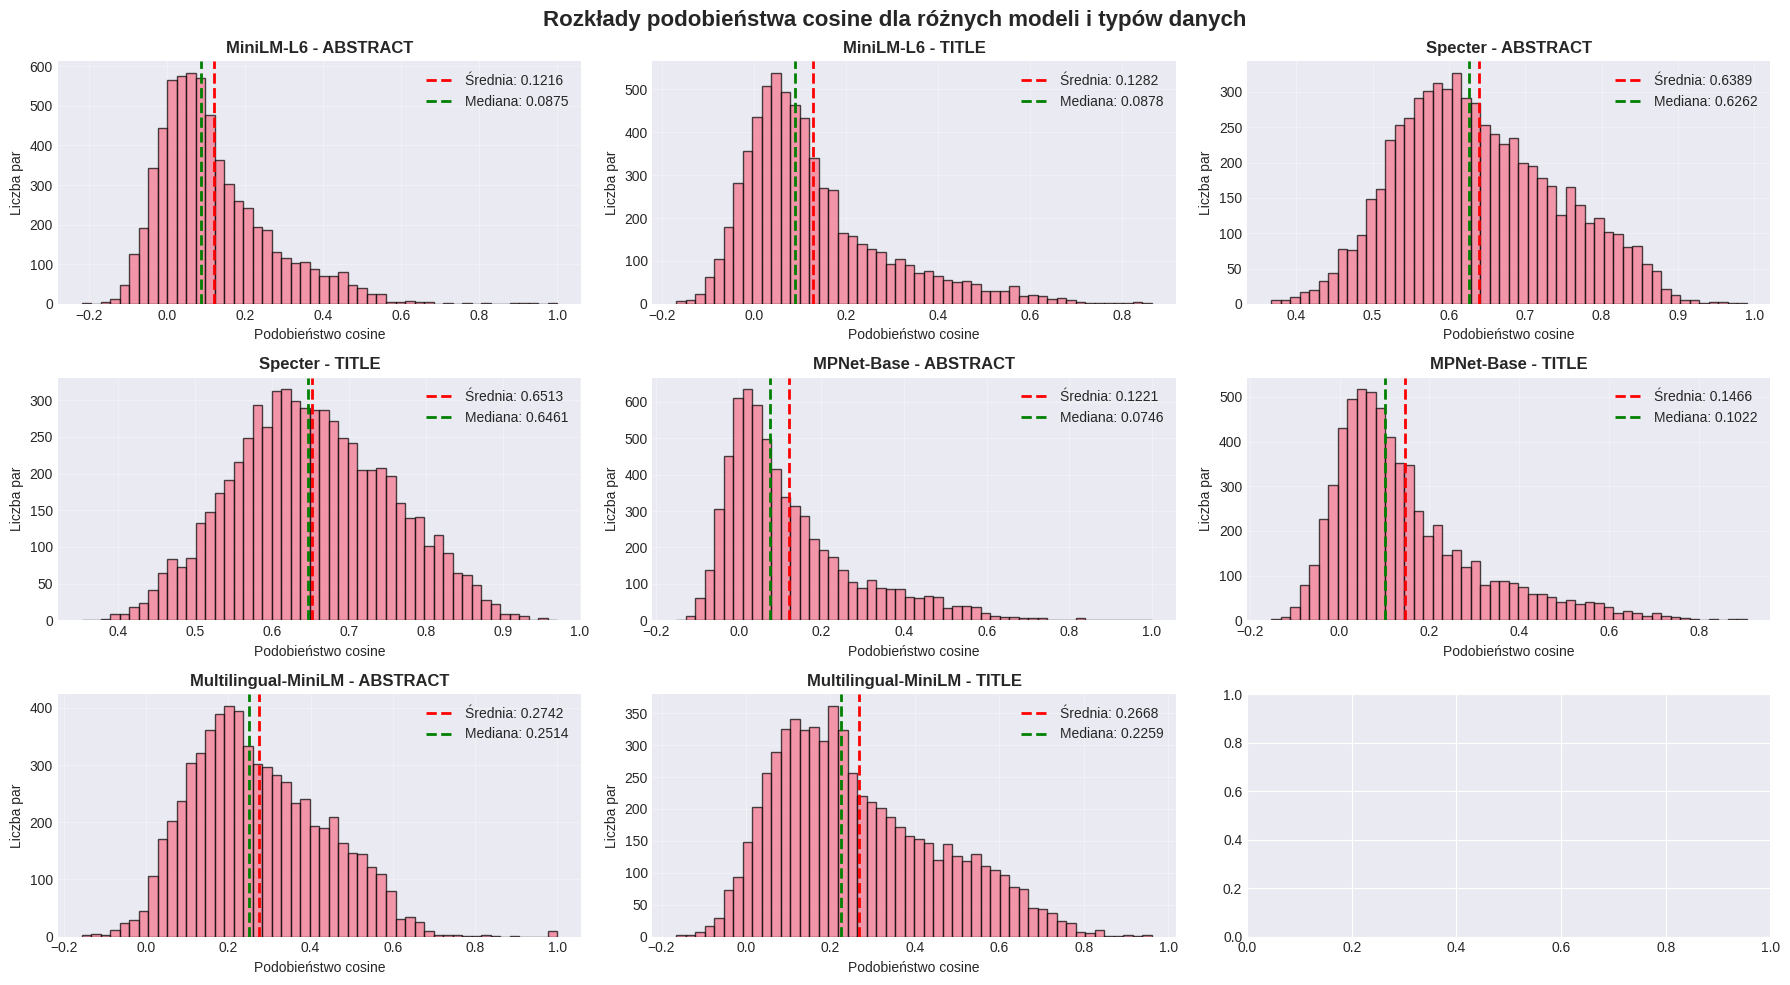

In [ ]:
# Wykres porównawczy rozkładów podobieństwa
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Rozkłady podobieństwa cosine dla różnych modeli i typów danych',
             fontsize=16, fontweight='bold')

for idx, (key, result) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    values = result['stats']['values']

    ax.hist(values, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(result['stats']['mean'], color='red', linestyle='--',
               linewidth=2, label=f"Średnia: {result['stats']['mean']:.4f}")
    ax.axvline(result['stats']['median'], color='green', linestyle='--',
               linewidth=2, label=f"Mediana: {result['stats']['median']:.4f}")

    ax.set_title(f"{result['model_name']} - {result['embedding_type'].upper()}",
                fontweight='bold')
    ax.set_xlabel('Podobieństwo cosine')
    ax.set_ylabel('Liczba par')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

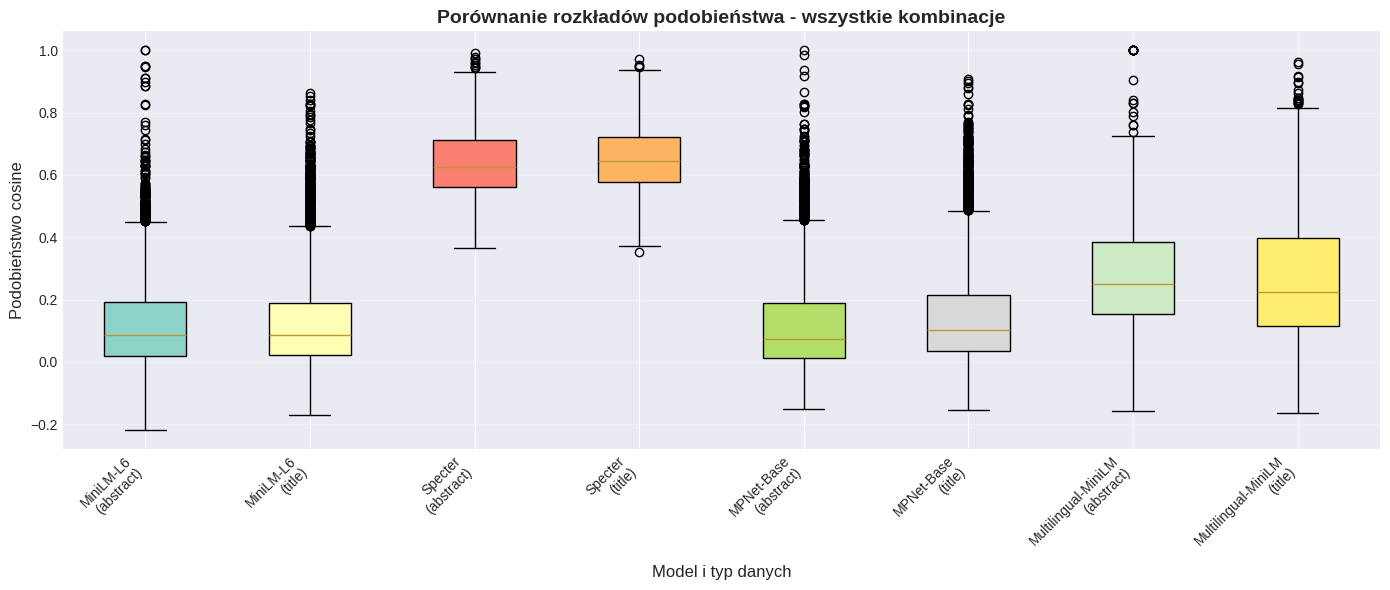

In [ ]:
# Wykres pudełkowy porównujący wszystkie kombinacje
fig, ax = plt.subplots(figsize=(14, 6))

data_for_boxplot = []
labels = []

for key, result in results.items():
    data_for_boxplot.append(result['stats']['values'])
    labels.append(f"{result['model_name']}\n({result['embedding_type']})")

bp = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True)

# Kolorowanie pudełek
colors = plt.cm.Set3(np.linspace(0, 1, len(results)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Porównanie rozkładów podobieństwa - wszystkie kombinacje',
            fontsize=14, fontweight='bold')
ax.set_ylabel('Podobieństwo cosine', fontsize=12)
ax.set_xlabel('Model i typ danych', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

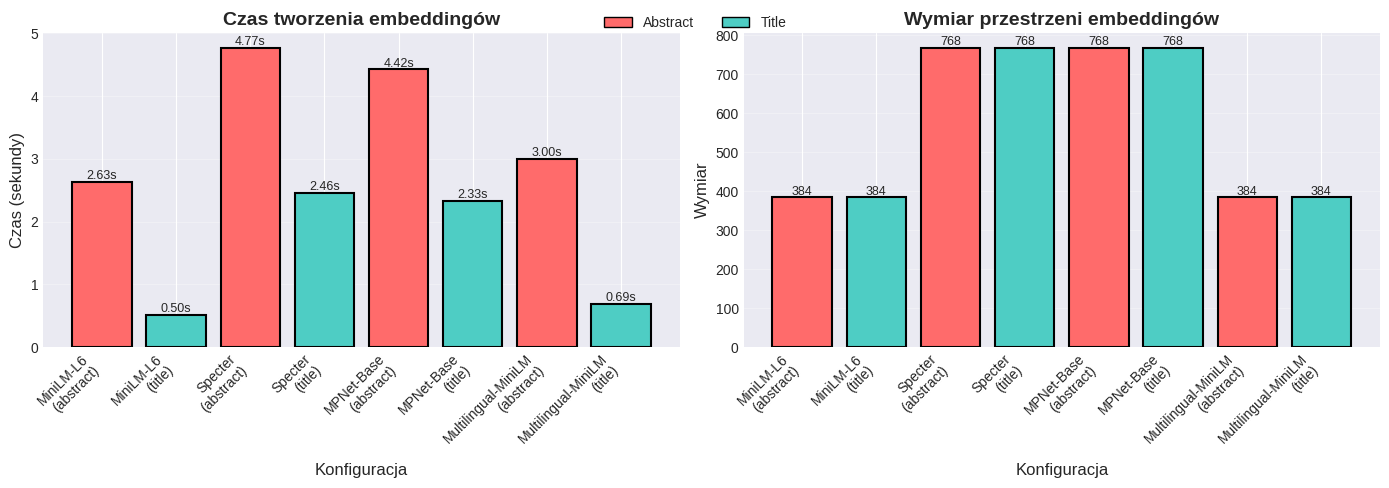

In [ ]:
# Wykres czasu embedowania
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models_list = [r['model_name'] for r in results.values()]
types_list = [r['embedding_type'] for r in results.values()]
embed_times = [r['embed_time'] for r in results.values()]
dims = [r['embedding_dim'] for r in results.values()]

# Czas embedowania
x = np.arange(len(results))
colors_bar = ['#FF6B6B' if t == 'abstract' else '#4ECDC4' for t in types_list]
bars1 = ax1.bar(x, embed_times, color=colors_bar, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Konfiguracja', fontsize=12)
ax1.set_ylabel('Czas (sekundy)', fontsize=12)
ax1.set_title('Czas tworzenia embeddingów', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{m}\n({t})" for m, t in zip(models_list, types_list)],
                     rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Dodanie wartości na słupkach
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s',
            ha='center', va='bottom', fontsize=9)

# Wymiar embeddingów
bars2 = ax2.bar(x, dims, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Konfiguracja', fontsize=12)
ax2.set_ylabel('Wymiar', fontsize=12)
ax2.set_title('Wymiar przestrzeni embeddingów', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{m}\n({t})" for m, t in zip(models_list, types_list)],
                     rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Dodanie wartości na słupkach
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Abstract'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Title')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.98))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 10. Analiza najbardziej podobnych autorów

Dla wybranego modelu sprawdzamy, którzy autorzy są najbardziej do siebie podobni.

In [ ]:
# =============================================================================
# ANALIZA NAJBARDZIEJ PODOBNYCH AUTORÓW
# =============================================================================

# Wybierz konfigurację do analizy
config_to_analyze = 'MPNet-Base_abstract'  # Zmień na dowolną kombinację

if config_to_analyze in embeddings_storage:
    print(f"\n{'='*80}")
    print(f"ANALIZA PODOBIEŃSTWA AUTORÓW: {config_to_analyze}")
    print(f"{'='*80}\n")

    # Przygotowanie mapowania ORCID -> Nazwisko
    # Zakładamy, że df_scientists ma kolumny: 'clean_orcid' i nazwisko (np. 'family_name' lub 'full_name')
    # DOSTOSUJ nazwę kolumny z nazwiskiem do swojego DataFrame!

    # Sprawdź dostępne kolumny z nazwiskiem
    possible_name_columns = ['family_name', 'full_name', 'name', 'surname',
                              'last_name', 'display_name', 'author_name']
    name_column = None

    for col in possible_name_columns:
        if col in df_scientists.columns:
            name_column = col
            break

    if name_column is None:
        print("⚠️  Nie znaleziono kolumny z nazwiskiem!")
        print(f"   Dostępne kolumny: {df_scientists.columns.tolist()}")
        print("   Ustaw 'name_column' ręcznie, np.: name_column = 'family_name'")
    else:
        print(f"✅ Używam kolumny: '{name_column}' dla nazwisk\n")

        # Tworzenie mapowania ORCID -> Nazwisko
        orcid_to_name = dict(zip(
            df_scientists['clean_orcid'],
            df_scientists[name_column]
        ))

        # Dodajemy mapowanie również dla author_data
        author_data['author_name'] = author_data['author_id'].map(orcid_to_name)

        # Obliczenie podobieństwa
        embeddings = embeddings_storage[config_to_analyze]
        similar_authors = find_most_similar_authors(embeddings, authors, top_n=5)

        # Funkcja pomocnicza do wyświetlania nazwiska
        def get_author_name(orcid):
            """Zwraca nazwisko autora lub ORCID jeśli nazwisko nie jest dostępne."""
            name = orcid_to_name.get(orcid, orcid)
            return name if pd.notna(name) else orcid

        # =====================================================================
        # OPCJA 1: Wyświetl 10 losowych autorów
        # =====================================================================
        print("📋 10 PRZYKŁADOWYCH AUTORÓW I ICH NAJBARDZIEJ PODOBNI KOLEDZY:\n")
        print("="*80)

        for i, (author_orcid, similar_list) in enumerate(list(similar_authors.items())[:10]):
            author_name = get_author_name(author_orcid)

            print(f"\n{i+1}. {author_name}")
            print(f"   (ORCID: {author_orcid})")
            print("   Najbardziej podobni:")

            for rank, (sim_orcid, score) in enumerate(similar_list, 1):
                sim_name = get_author_name(sim_orcid)
                print(f"      {rank}. {sim_name} (podobieństwo: {score:.4f})")
                print(f"         ORCID: {sim_orcid}")

        # =====================================================================
        # OPCJA 2: Wyszukaj konkretnego autora po nazwisku
        # =====================================================================
        print(f"\n\n{'='*80}")
        print("🔍 WYSZUKIWANIE KONKRETNEGO AUTORA")
        print("="*80)

        # ZMIEŃ TO NAZWISKO NA AUTORA, KTÓREGO CHCESZ ZNALEŹĆ
        search_name = "Żywica"  # Wpisz fragment nazwiska do wyszukania

        # Wyszukiwanie autorów pasujących do nazwiska
        matching_authors = author_data[
            author_data['author_name'].str.contains(search_name, case=False, na=False)
        ]

        if len(matching_authors) == 0:
            print(f"\n❌ Nie znaleziono autora pasującego do: '{search_name}'")
            print(f"\n💡 Dostępni autorzy (pierwsze 20):")
            for idx, name in enumerate(author_data['author_name'].dropna().head(20), 1):
                print(f"   {idx}. {name}")
        else:
            print(f"\n✅ Znaleziono {len(matching_authors)} autor(ów) pasujących do: '{search_name}'")
            print()

            for idx, row in matching_authors.iterrows():
                author_orcid = row['author_id']
                author_name = row['author_name']

                print(f"\n{'─'*80}")
                print(f"👤 AUTOR: {author_name}")
                print(f"   ORCID: {author_orcid}")
                print(f"{'─'*80}")

                if author_orcid in similar_authors:
                    print("   Najbardziej podobni autorzy:")

                    for rank, (sim_orcid, score) in enumerate(similar_authors[author_orcid], 1):
                        sim_name = get_author_name(sim_orcid)
                        print(f"\n      {rank}. {sim_name}")
                        print(f"         Podobieństwo: {score:.4f}")
                        print(f"         ORCID: {sim_orcid}")
                else:
                    print("   ⚠️  Brak danych o podobieństwie dla tego autora")

        # =====================================================================
        # OPCJA 3: Interaktywne wyszukiwanie (opcjonalne)
        # =====================================================================
        print(f"\n\n{'='*80}")
        print("💡 WSKAZÓWKA: INTERAKTYWNE WYSZUKIWANIE")
        print("="*80)
        print("\nAby wyszukać konkretnego autora, zmień wartość zmiennej 'search_name'")
        print("w sekcji 'OPCJA 2' powyżej i uruchom komórkę ponownie.")
        print("\nPrzykłady:")
        print("  search_name = 'Smith'")
        print("  search_name = 'Kowalski'")
        print("  search_name = 'Wang'")

        # Statystyki
        print(f"\n\n{'='*80}")
        print("📊 STATYSTYKI")
        print("="*80)
        print(f"Łączna liczba autorów w analizie: {len(similar_authors)}")
        print(f"Autorzy z przypisanymi nazwiskami: {author_data['author_name'].notna().sum()}")
        print(f"Autorzy bez nazwisk: {author_data['author_name'].isna().sum()}")

else:
    print(f"❌ Konfiguracja '{config_to_analyze}' nie została znaleziona.")
    print(f"📋 Dostępne konfiguracje: {list(embeddings_storage.keys())}")


ANALIZA PODOBIEŃSTWA AUTORÓW: MPNet-Base_abstract

✅ Używam kolumny: 'full_name' dla nazwisk

📋 10 PRZYKŁADOWYCH AUTORÓW I ICH NAJBARDZIEJ PODOBNI KOLEDZY:


1. dr Michał Goliński
   (ORCID: 0000-0001-5016-1433)
   Najbardziej podobni:
      1. dr Adam Przestacki (podobieństwo: 0.9367)
         ORCID: 0000-0002-5395-3038
      2. dr Paweł Mleczko (podobieństwo: 0.7155)
         ORCID: 0000-0001-9540-1293
      3. dr Michał Rzeczkowski (podobieństwo: 0.6960)
         ORCID: 0000-0003-4036-3044
      4. prof. UAM dr hab. Krzysztof Piszczek (podobieństwo: 0.6497)
         ORCID: 0000-0002-5732-2743
      5. prof. UAM dr hab. Michał Jasiczak (podobieństwo: 0.6269)
         ORCID: 0000-0003-1010-1430

2. dr inż. Michał Krzysztof Ren
   (ORCID: 0000-0001-5386-5487)
   Najbardziej podobni:
      1. prof. dr hab. Roman Murawski (podobieństwo: 0.3429)
         ORCID: 0000-0002-2392-4869
      2. dr Mirosława Kołowska-Gawiejnowicz (podobieństwo: 0.3256)
         ORCID: 0000-0003-1333-6438
     

## 11. Porównanie: Abstract vs Title dla tego samego modelu

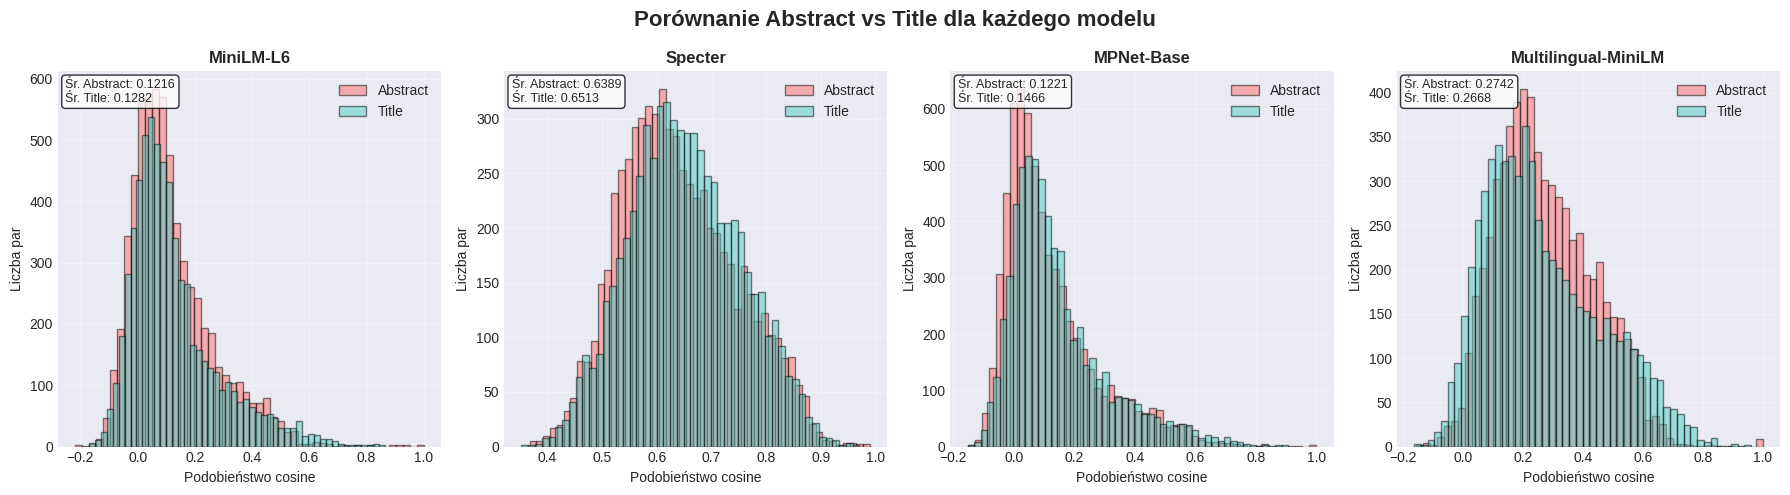

In [ ]:
# Porównanie dla każdego modelu osobno
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Porównanie Abstract vs Title dla każdego modelu',
             fontsize=16, fontweight='bold')

for idx, model_name in enumerate(MODELS.keys()):
    ax = axes[idx]

    abstract_key = f"{model_name}_abstract"
    title_key = f"{model_name}_title"

    abstract_values = results[abstract_key]['stats']['values']
    title_values = results[title_key]['stats']['values']

    ax.hist(abstract_values, bins=50, alpha=0.5, label='Abstract',
            color='#FF6B6B', edgecolor='black')
    ax.hist(title_values, bins=50, alpha=0.5, label='Title',
            color='#4ECDC4', edgecolor='black')

    ax.set_title(model_name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Podobieństwo cosine')
    ax.set_ylabel('Liczba par')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Dodaj statystyki
    abs_mean = results[abstract_key]['stats']['mean']
    title_mean = results[title_key]['stats']['mean']
    ax.text(0.02, 0.98,
            f"Śr. Abstract: {abs_mean:.4f}\nŚr. Title: {title_mean:.4f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 12. Zapisanie wyników

In [ ]:
# Zapis tabeli podsumowującej
summary_df.to_csv('../results/model_comparison/embedding_experiment_summary.csv', index=False)
print("✓ Tabela podsumowująca zapisana do: ../results/model_comparison/embedding_experiment_summary.csv")

# Zapis embeddingów (opcjonalnie)
# for key, embeddings in embeddings_storage.items():
#     np.save(f'embeddings_{key}.npy', embeddings)
#     print(f"✓ Embeddingi zapisane do: embeddings_{key}.npy")

✓ Tabela podsumowująca zapisana do: ../results/model_comparison/embedding_experiment_summary.csv



📊 WIZUALIZACJA PCA DLA: MPNet-Base_abstract

✅ Załadowano embeddingi:
   Liczba autorów: 114
   Wymiar embeddingów: 768

🔄 Wykonywanie redukcji PCA do 2D...
✅ PCA zakończone:
   PC1 wyjaśnia: 12.05% wariancji
   PC2 wyjaśnia: 7.17% wariancji
   Łącznie: 19.22% wariancji

📈 Tworzenie wizualizacji...


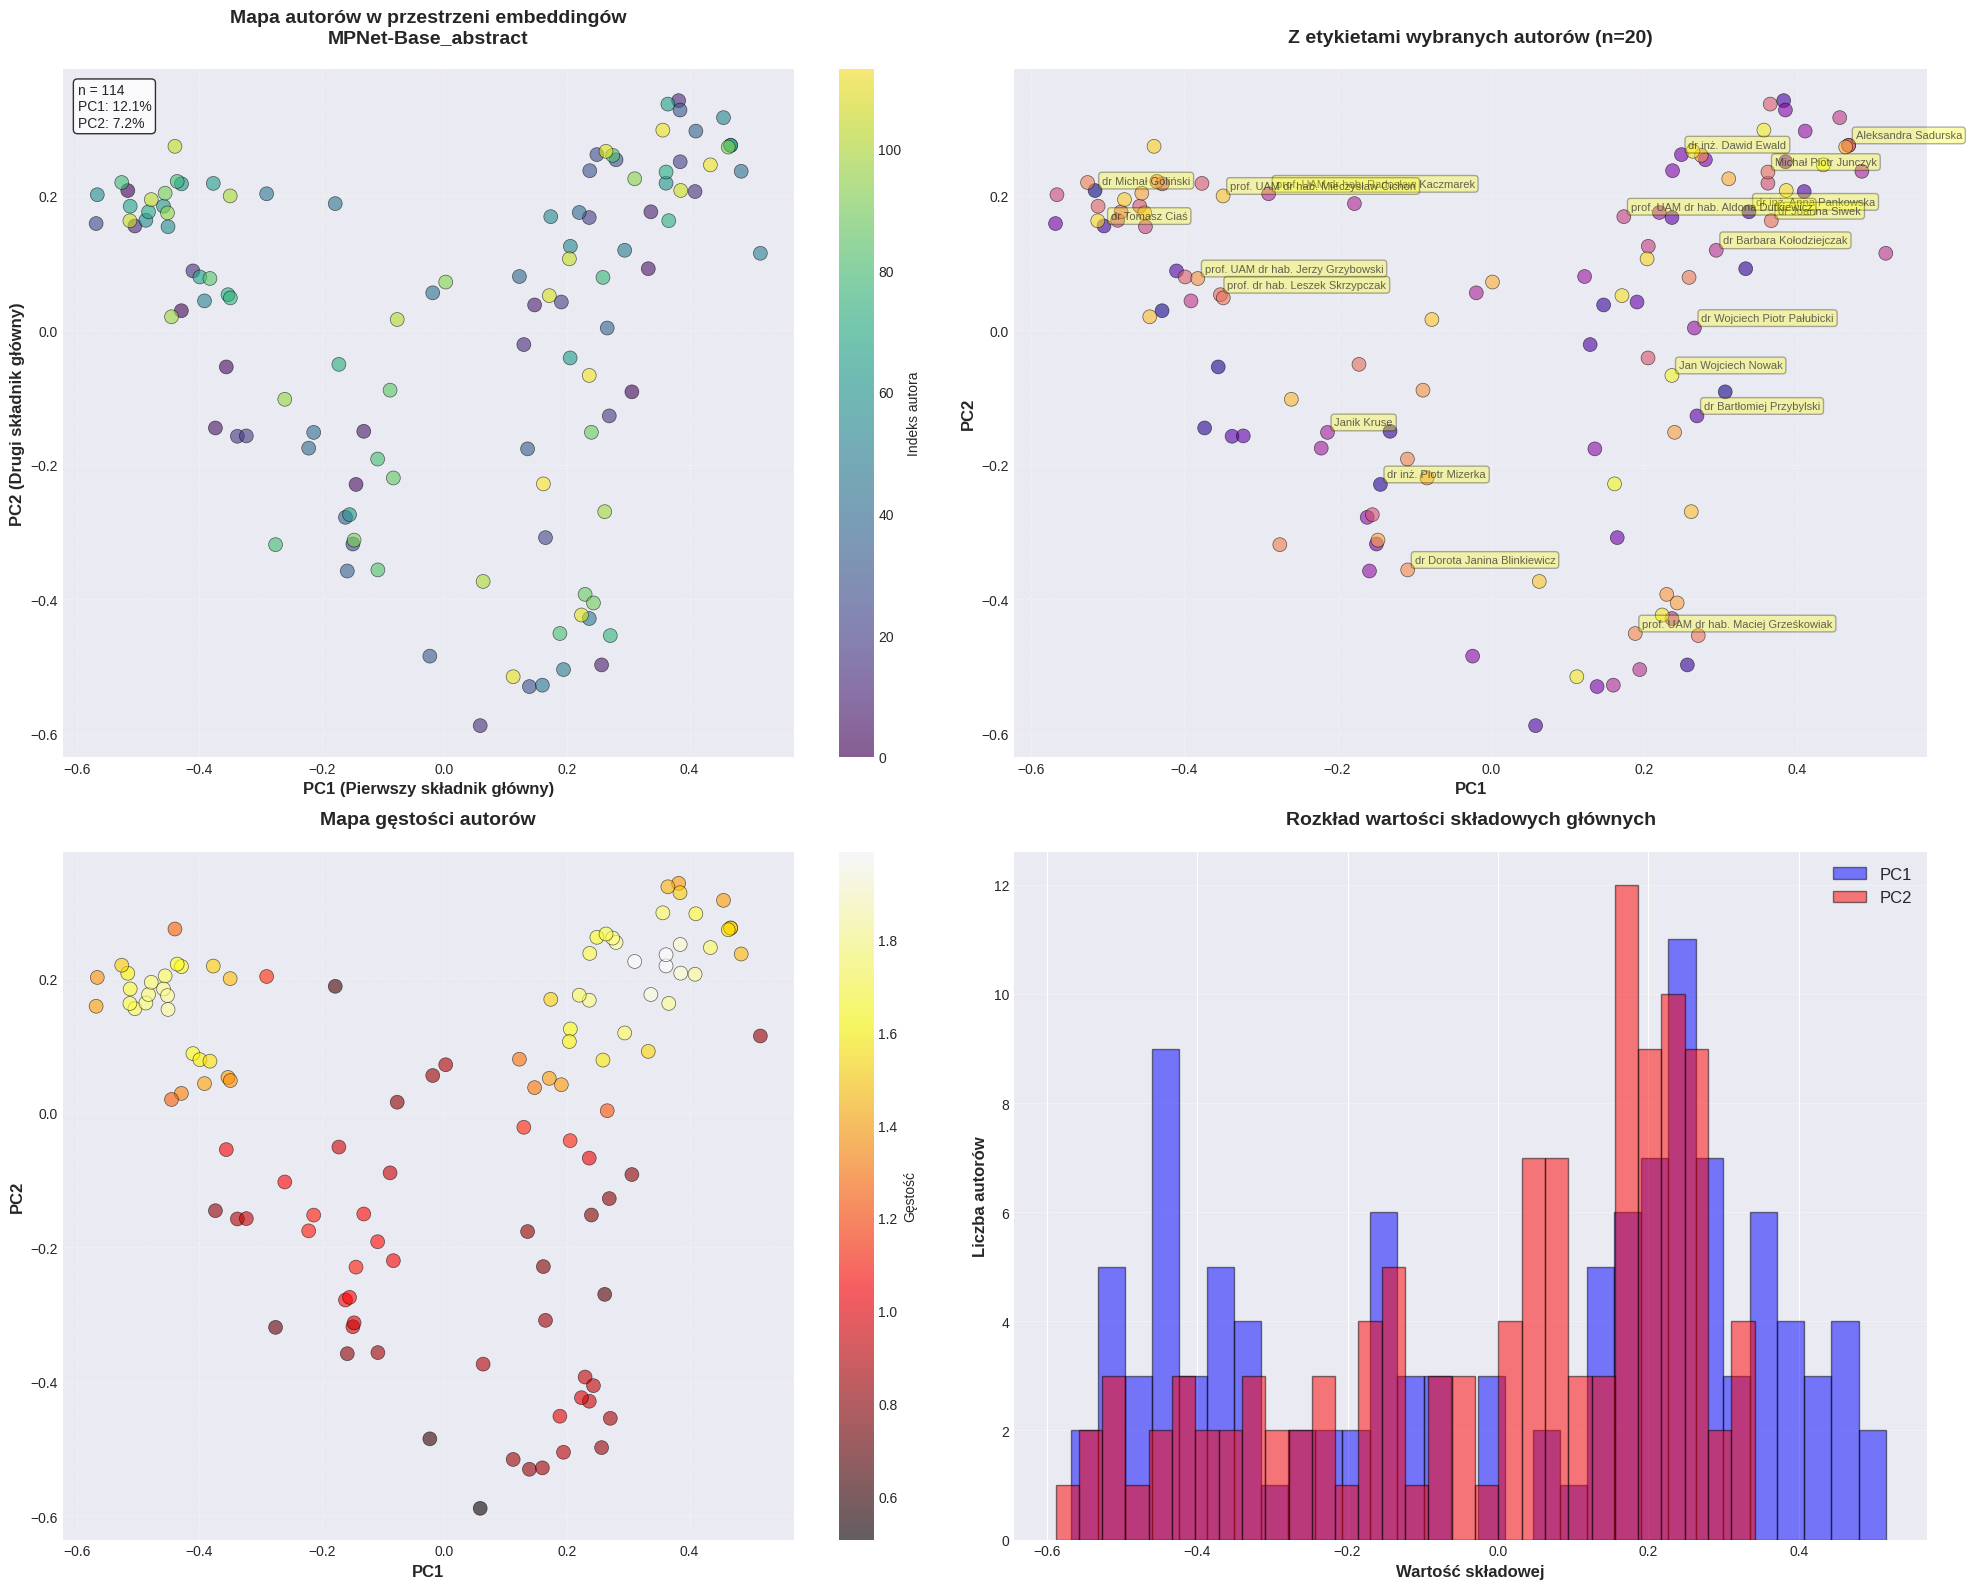


🔍 WYSZUKIWANIE I PODŚWIETLANIE AUTORA NA MAPIE

❌ Nie znaleziono: 'Einstein'

📊 STATYSTYKI

PC1: min=-0.5681, max=0.5156, śr=0.0000, std=0.3239
PC2: min=-0.5883, max=0.3412, śr=0.0000, std=0.2497

✅ Współrzędne zapisane w author_data (pca_x, pca_y)


In [ ]:
# =============================================================================
# WIZUALIZACJA PCA - MAPA AUTORÓW W PRZESTRZENI EMBEDDINGÓW
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Wybierz konfigurację do wizualizacji
config_to_visualize = 'MPNet-Base_abstract'  # Zmień na dowolną kombinację

print(f"\n{'='*80}")
print(f"📊 WIZUALIZACJA PCA DLA: {config_to_visualize}")
print(f"{'='*80}\n")

if config_to_visualize not in embeddings_storage:
    print(f"❌ Konfiguracja '{config_to_visualize}' nie została znaleziona.")
    print(f"📋 Dostępne konfiguracje: {list(embeddings_storage.keys())}")
else:
    # Pobierz embeddingi
    embeddings = embeddings_storage[config_to_visualize]

    print(f"✅ Załadowano embeddingi:")
    print(f"   Liczba autorów: {len(embeddings)}")
    print(f"   Wymiar embeddingów: {embeddings.shape[1]}")

    # Wykonaj PCA do 2 wymiarów
    print(f"\n🔄 Wykonywanie redukcji PCA do 2D...")
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    # Informacje o PCA
    explained_variance = pca.explained_variance_ratio_
    print(f"✅ PCA zakończone:")
    print(f"   PC1 wyjaśnia: {explained_variance[0]*100:.2f}% wariancji")
    print(f"   PC2 wyjaśnia: {explained_variance[1]*100:.2f}% wariancji")
    print(f"   Łącznie: {sum(explained_variance)*100:.2f}% wariancji")

    # Przygotowanie danych do wizualizacji
    x_coords = embeddings_2d[:, 0]
    y_coords = embeddings_2d[:, 1]

    # Mapowanie ORCID -> Nazwisko (jeśli dostępne)
    if 'author_name' in author_data.columns:
        labels = author_data['author_name'].fillna(author_data['author_id']).tolist()
        has_names = True
    else:
        labels = authors  # Używamy ORCID
        has_names = False

    # ==========================================================================
    # WYKRES 1: Podstawowa mapa rozrzutu (2x2)
    # ==========================================================================
    print(f"\n📈 Tworzenie wizualizacji...")

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    # Wykres 1.1: Wszystkie punkty
    ax = axes[0, 0]
    scatter = ax.scatter(x_coords, y_coords,
                        alpha=0.6,
                        s=100,
                        c=range(len(x_coords)),
                        cmap='viridis',
                        edgecolors='black',
                        linewidth=0.5)

    ax.set_xlabel('PC1 (Pierwszy składnik główny)', fontsize=12, fontweight='bold')
    ax.set_ylabel('PC2 (Drugi składnik główny)', fontsize=12, fontweight='bold')
    ax.set_title(f'Mapa autorów w przestrzeni embeddingów\n{config_to_visualize}',
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Indeks autora', fontsize=10)

    stats_text = f"n = {len(embeddings)}\nPC1: {explained_variance[0]*100:.1f}%\nPC2: {explained_variance[1]*100:.1f}%"
    ax.text(0.02, 0.98, stats_text,
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Wykres 1.2: Z etykietami (20 losowych)
    ax = axes[0, 1]
    ax.scatter(x_coords, y_coords, alpha=0.6, s=100,
              c=range(len(x_coords)), cmap='plasma',
              edgecolors='black', linewidth=0.5)

    np.random.seed(42)
    indices_to_label = np.random.choice(len(labels), min(20, len(labels)), replace=False)

    for idx in indices_to_label:
        ax.annotate(labels[idx], (x_coords[idx], y_coords[idx]),
                   xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

    ax.set_xlabel('PC1', fontsize=12, fontweight='bold')
    ax.set_ylabel('PC2', fontsize=12, fontweight='bold')
    ax.set_title(f'Z etykietami wybranych autorów (n=20)',
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Wykres 2.1: Mapa gęstości
    ax = axes[1, 0]
    from scipy.stats import gaussian_kde

    xy = np.vstack([x_coords, y_coords])
    z = gaussian_kde(xy)(xy)

    scatter = ax.scatter(x_coords, y_coords, c=z, s=100, cmap='hot',
                        alpha=0.6, edgecolors='black', linewidth=0.5)

    ax.set_xlabel('PC1', fontsize=12, fontweight='bold')
    ax.set_ylabel('PC2', fontsize=12, fontweight='bold')
    ax.set_title('Mapa gęstości autorów', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Gęstość', fontsize=10)

    # Wykres 2.2: Histogramy
    ax = axes[1, 1]
    ax.hist(x_coords, bins=30, alpha=0.5, label='PC1', color='blue', edgecolor='black')
    ax.hist(y_coords, bins=30, alpha=0.5, label='PC2', color='red', edgecolor='black')

    ax.set_xlabel('Wartość składowej', fontsize=12, fontweight='bold')
    ax.set_ylabel('Liczba autorów', fontsize=12, fontweight='bold')
    ax.set_title('Rozkład wartości składowych głównych',
                fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # ==========================================================================
    # WYKRES 2: Interaktywna mapa z wyszukiwaniem
    # ==========================================================================
    print(f"\n{'='*80}")
    print("🔍 WYSZUKIWANIE I PODŚWIETLANIE AUTORA NA MAPIE")
    print("="*80)

    # ZMIEŃ NAZWISKO DO WYSZUKANIA
    highlight_name = "Einstein"

    if has_names:
        matching_indices = [i for i, name in enumerate(labels)
                           if highlight_name.lower() in str(name).lower()]
    else:
        matching_indices = [i for i, orcid in enumerate(labels)
                           if highlight_name in orcid]

    if matching_indices:
        print(f"\n✅ Znaleziono {len(matching_indices)} autor(ów): '{highlight_name}'")

        fig, ax = plt.subplots(figsize=(14, 10))

        # Tło - wszyscy autorzy
        ax.scatter(x_coords, y_coords, alpha=0.3, s=80, c='lightgray',
                  edgecolors='gray', linewidth=0.3, label='Inni autorzy')

        # Podświetleni autorzy
        highlight_x = [x_coords[i] for i in matching_indices]
        highlight_y = [y_coords[i] for i in matching_indices]
        highlight_labels = [labels[i] for i in matching_indices]

        ax.scatter(highlight_x, highlight_y, alpha=0.9, s=300, c='red',
                  edgecolors='darkred', linewidth=2, marker='*',
                  label=f'Znalezieni: {highlight_name}', zorder=5)

        for x, y, label in zip(highlight_x, highlight_y, highlight_labels):
            ax.annotate(label, (x, y), xytext=(10, 10),
                       textcoords='offset points', fontsize=12, fontweight='bold',
                       color='darkred',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow',
                               edgecolor='darkred', alpha=0.8, linewidth=2),
                       arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

        # 5 najbliższych sąsiadów
        idx = matching_indices[0]
        distances = np.sqrt((x_coords - x_coords[idx])**2 + (y_coords - y_coords[idx])**2)
        nearest_indices = np.argsort(distances)[1:6]

        nearest_x = [x_coords[i] for i in nearest_indices]
        nearest_y = [y_coords[i] for i in nearest_indices]
        nearest_labels = [labels[i] for i in nearest_indices]

        ax.scatter(nearest_x, nearest_y, alpha=0.7, s=200, c='orange',
                  edgecolors='darkorange', linewidth=2, marker='o',
                  label='5 najbliższych', zorder=4)

        for x, y, label in zip(nearest_x, nearest_y, nearest_labels):
            ax.annotate(label, (x, y), xytext=(5, -10),
                       textcoords='offset points', fontsize=9, color='darkorange',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

        ax.set_xlabel('PC1', fontsize=12, fontweight='bold')
        ax.set_ylabel('PC2', fontsize=12, fontweight='bold')
        ax.set_title(f'Wyszukiwanie: "{highlight_name}"\n{config_to_visualize}',
                    fontsize=14, fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)

        plt.tight_layout()
        plt.show()

        print(f"\n📍 POZYCJE:")
        for i, idx in enumerate(matching_indices, 1):
            print(f"{i}. {labels[idx]}")
            print(f"   PCA: ({x_coords[idx]:.4f}, {y_coords[idx]:.4f})")
    else:
        print(f"\n❌ Nie znaleziono: '{highlight_name}'")

    # Statystyki
    print(f"\n{'='*80}")
    print("📊 STATYSTYKI")
    print("="*80)
    print(f"\nPC1: min={x_coords.min():.4f}, max={x_coords.max():.4f}, "
          f"śr={x_coords.mean():.4f}, std={x_coords.std():.4f}")
    print(f"PC2: min={y_coords.min():.4f}, max={y_coords.max():.4f}, "
          f"śr={y_coords.mean():.4f}, std={y_coords.std():.4f}")

    # Zapisz współrzędne
    author_data['pca_x'] = x_coords
    author_data['pca_y'] = y_coords

    print(f"\n✅ Współrzędne zapisane w author_data (pca_x, pca_y)")

In [ ]:
# =============================================================================
# INTERAKTYWNA MAPA PCA AUTORÓW
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import plotly.graph_objects as go
import plotly.express as px




def vis_conf(config):
  config_to_visualize = config  # Zmień na dowolną kombinację
  # Wybierz konfigurację do wizualizacji
  # config_to_visualize = 'MPNet-Base_abstract'  # Zmień na dowolną kombinację

  print(f"\n{'='*80}")
  print(f"📊 INTERAKTYWNA MAPA PCA: {config_to_visualize}")
  print(f"{'='*80}\n")

  if config_to_visualize not in embeddings_storage:
      print(f"❌ Konfiguracja '{config_to_visualize}' nie została znaleziona.")
      print(f"📋 Dostępne konfiguracje: {list(embeddings_storage.keys())}")
  else:
      # Pobierz embeddingi
      embeddings = embeddings_storage[config_to_visualize]

      print(f"✅ Załadowano embeddingi:")
      print(f"   Liczba autorów: {len(embeddings)}")
      print(f"   Wymiar embeddingów: {embeddings.shape[1]}")

      # Wykonaj PCA do 2 wymiarów
      print(f"\n🔄 Wykonywanie redukcji PCA do 2D...")
      pca = PCA(n_components=2)
      embeddings_2d = pca.fit_transform(embeddings)

      # Informacje o PCA
      explained_variance = pca.explained_variance_ratio_
      print(f"✅ PCA zakończone:")
      print(f"   PC1 wyjaśnia: {explained_variance[0]*100:.2f}% wariancji")
      print(f"   PC2 wyjaśnia: {explained_variance[1]*100:.2f}% wariancji")
      print(f"   Łącznie: {sum(explained_variance)*100:.2f}% wariancji")

      # Przygotowanie danych
      x_coords = embeddings_2d[:, 0]
      y_coords = embeddings_2d[:, 1]

      # Mapowanie ORCID -> Nazwisko
      if 'author_name' in author_data.columns:
          labels = author_data['author_name'].fillna(author_data['author_id']).tolist()
      else:
          labels = authors

      # Przygotuj DataFrame do Plotly
      import pandas as pd
      plot_df = pd.DataFrame({
          'PC1': x_coords,
          'PC2': y_coords,
          'Autor': labels,
          'ORCID': authors
      })

      # Dodaj informacje o liczbie publikacji
      if 'author_id' in author_data.columns:
          works_count = df_clean.groupby('clean_orcid').size()
          plot_df['Liczba_publikacji'] = plot_df['ORCID'].map(works_count).fillna(0).astype(int)

      # Stwórz interaktywny wykres
      print(f"\n📈 Tworzenie interaktywnej mapy...")

      fig = go.Figure()

      fig.add_trace(go.Scatter(
          x=plot_df['PC1'],
          y=plot_df['PC2'],
          mode='markers',
          marker=dict(
              size=10,
              color=plot_df.index,
              colorscale='Viridis',
              showscale=True,
              colorbar=dict(title="Indeks<br>autora"),
              line=dict(width=1, color='white')
          ),
          text=plot_df['Autor'],
          customdata=np.column_stack((
              plot_df['ORCID'],
              plot_df['Liczba_publikacji'] if 'Liczba_publikacji' in plot_df.columns else ['N/A']*len(plot_df)
          )),
          hovertemplate='<b>%{text}</b><br>' +
                        'PC1: %{x:.4f}<br>' +
                        'PC2: %{y:.4f}<br>' +
                        'ORCID: %{customdata[0]}<br>' +
                        'Publikacji: %{customdata[1]}<br>' +
                        '<extra></extra>',
          name='Autorzy'
      ))

      # Konfiguracja layoutu
      fig.update_layout(
          title=dict(
              text=f'Interaktywna mapa autorów w przestrzeni embeddingów<br>' +
                  f'<sub>{config_to_visualize}</sub><br>' +
                  f'<sub>PC1: {explained_variance[0]*100:.1f}% | PC2: {explained_variance[1]*100:.1f}% | Łącznie: {sum(explained_variance)*100:.1f}%</sub>',
              x=0.5,
              xanchor='center',
              font=dict(size=16)
          ),
          xaxis=dict(
              title=f'PC1 (wyjaśnia {explained_variance[0]*100:.1f}% wariancji)',
              gridcolor='lightgray',
              showgrid=True,
              zeroline=True,
              zerolinewidth=2,
              zerolinecolor='gray'
          ),
          yaxis=dict(
              title=f'PC2 (wyjaśnia {explained_variance[1]*100:.1f}% wariancji)',
              gridcolor='lightgray',
              showgrid=True,
              zeroline=True,
              zerolinewidth=2,
              zerolinecolor='gray'
          ),
          hovermode='closest',
          plot_bgcolor='white',
          width=1200,
          height=800,
          showlegend=False
      )

      # Wyświetl wykres
      fig.show()

      print(f"\n✅ Interaktywna mapa utworzona!")
      print(f"   💡 Najedź kursorem na punkt aby zobaczyć szczegóły autora")
      print(f"   💡 Użyj narzędzi w prawym górnym rogu do:")
      print(f"      - Przybliżania (zoom)")
      print(f"      - Przesuwania (pan)")
      print(f"      - Zaznaczania obszaru (box select)")
      print(f"      - Resetowania widoku")

      # Zapisz współrzędne
      author_data['pca_x'] = x_coords
      author_data['pca_y'] = y_coords

      print(f"\n✅ Współrzędne PCA zapisane w author_data (kolumny: pca_x, pca_y)")

In [ ]:
CONF = ['MiniLM-L6_abstract',
    'MiniLM-L6_title',
    'Specter_abstract',
    'Specter_title',
    'MPNet-Base_abstract',
    'MPNet-Base_title',
    'Multilingual-MiniLM_abstract',
    'Multilingual-MiniLM_title'

    ]

vis_conf("Specter_abstract")


📊 INTERAKTYWNA MAPA PCA: Specter_abstract

✅ Załadowano embeddingi:
   Liczba autorów: 114
   Wymiar embeddingów: 768

🔄 Wykonywanie redukcji PCA do 2D...
✅ PCA zakończone:
   PC1 wyjaśnia: 15.26% wariancji
   PC2 wyjaśnia: 7.19% wariancji
   Łącznie: 22.45% wariancji

📈 Tworzenie interaktywnej mapy...



✅ Interaktywna mapa utworzona!
   💡 Najedź kursorem na punkt aby zobaczyć szczegóły autora
   💡 Użyj narzędzi w prawym górnym rogu do:
      - Przybliżania (zoom)
      - Przesuwania (pan)
      - Zaznaczania obszaru (box select)
      - Resetowania widoku

✅ Współrzędne PCA zapisane w author_data (kolumny: pca_x, pca_y)


In [ ]:
vis_conf("MPNet-Base_abstract")


📊 INTERAKTYWNA MAPA PCA: MPNet-Base_abstract

✅ Załadowano embeddingi:
   Liczba autorów: 114
   Wymiar embeddingów: 768

🔄 Wykonywanie redukcji PCA do 2D...
✅ PCA zakończone:
   PC1 wyjaśnia: 12.05% wariancji
   PC2 wyjaśnia: 7.17% wariancji
   Łącznie: 19.22% wariancji

📈 Tworzenie interaktywnej mapy...



✅ Interaktywna mapa utworzona!
   💡 Najedź kursorem na punkt aby zobaczyć szczegóły autora
   💡 Użyj narzędzi w prawym górnym rogu do:
      - Przybliżania (zoom)
      - Przesuwania (pan)
      - Zaznaczania obszaru (box select)
      - Resetowania widoku

✅ Współrzędne PCA zapisane w author_data (kolumny: pca_x, pca_y)
